### 6-3. 배치 정규화



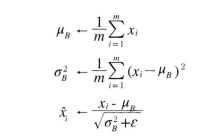
- 미니배치 B = [x_1,x_2,....,x_m]이라는 m개의 입력 데이터의 집합에 대해 평균과 분산을 구하여 입력 데이터를 평균이 0, 분산이 1이 되게 정규화한다.

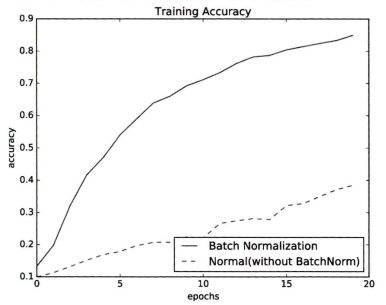

- 배치 정규화를 함으로써 정확도도 높아지고 학습 속도도 더 빨라져서 가중치 초깃값에 크게 의존하지 않아도 된다.

---

### 6-4. 바른 학습을 위해
- 매개변수가 많고 표현력이 높은 모델, 훈련 데이터가 적은 학습에서 오버피팅이 많이 일어난다. 
- 즉, 오버피팅을 줄여야 한다. -> ***오버피팅***을 줄이기 위해서 가중치를 감소시킨다. 
---

1. 가중치 감소
- W^2과 같이 가중치가 커질 때 가중치가 더 이상 늘어나는 것을 막기 위해 그 값을 손실함수에 더한다. -> 가중치가 커질수록 벌점이 늘어나서 가중치를 계속해서 조절해준다.

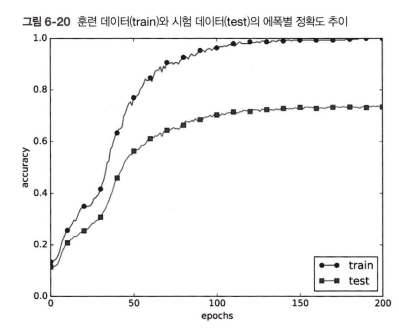

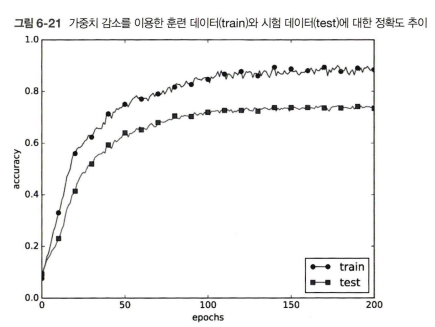

- 가중치 감소를 이용했을 때 오버피팅이 덜 되는 것을 확인할 수 있다.

----

2. 드롭아웃
###### 드롭아웃: 뉴런을 임의로 삭제하면서 학습하는 방법.
###### 훈련 때는 데이터를 흘릴 때마다 삭제할 뉴런을 무작위로 선택하고, 시험 때는 모든 뉴런에 신호를 전달한다.

In [1]:
import numpy as np

class Dropout:
    def __init__(self, dropout_ratio = 0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg = True):
        if train_flg: # 훈련 때면 True
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio)

    def backward(self, dout):
        return dout * self.mask
        

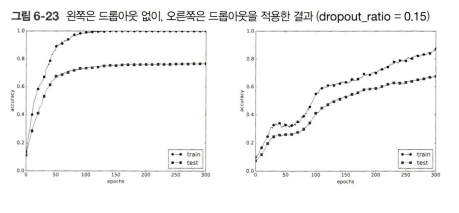

#### dropout을 적용한 결과 오버피팅이 많이 줄어드는 것을 확인할 수 있다.